<a href="https://colab.research.google.com/github/ab23ms233/deep-learning/blob/main/mnist_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setting up the environment

## Importing libraries

In [ ]:
# Tensorflow and Keras
from tensorflow.keras import Sequential
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Dense, Flatten

# Matplotlib, pandas, seaborn and numpy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# sklearn
from sklearn.metrics import accuracy_score

## Importing MNIST dataset

In [ ]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()
print(X_train.shape)
print(y_train)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
(60000, 28, 28)
[5 0 4 ... 5 6 8]


# Exploratory data analysis (EDA)

## Visualising data

### Training images

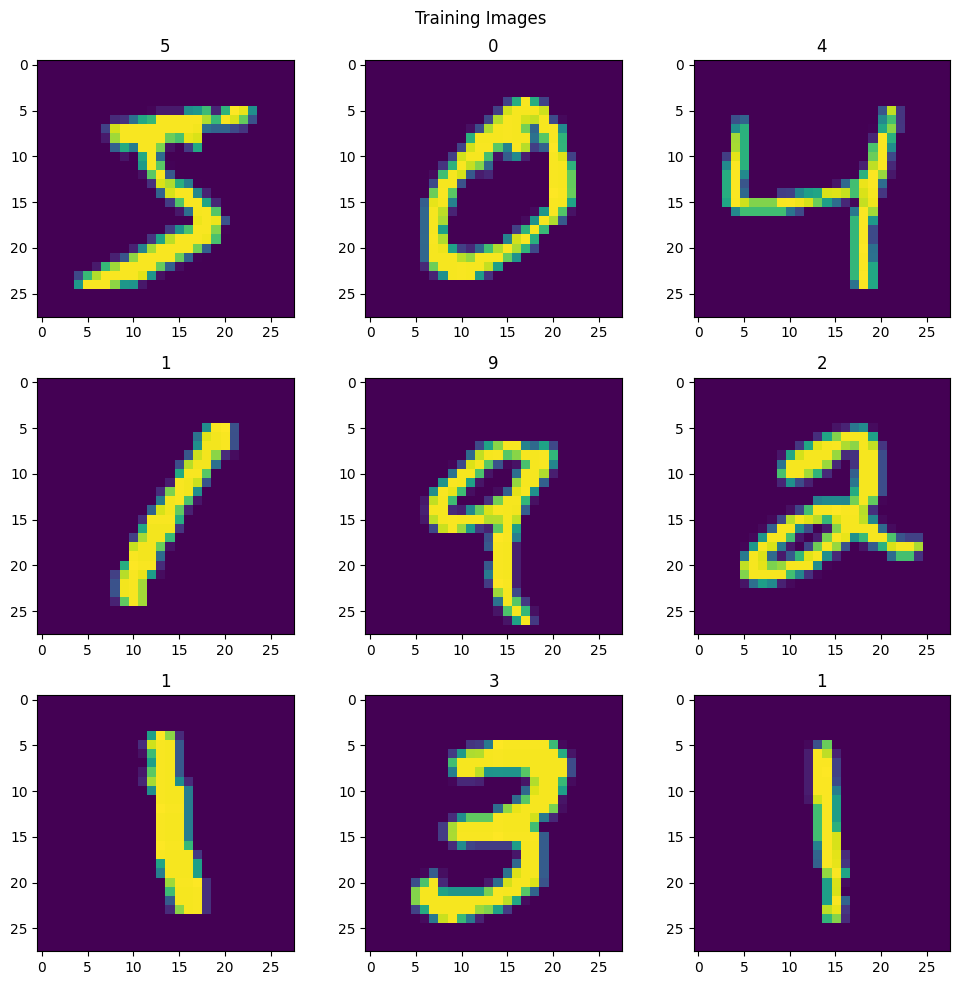

In [ ]:
plt.figure(figsize=(10, 10))

for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(X_train[i])
    plt.title(y_train[i])

plt.suptitle("Training Images")
plt.tight_layout()
plt.show()

### Testing images

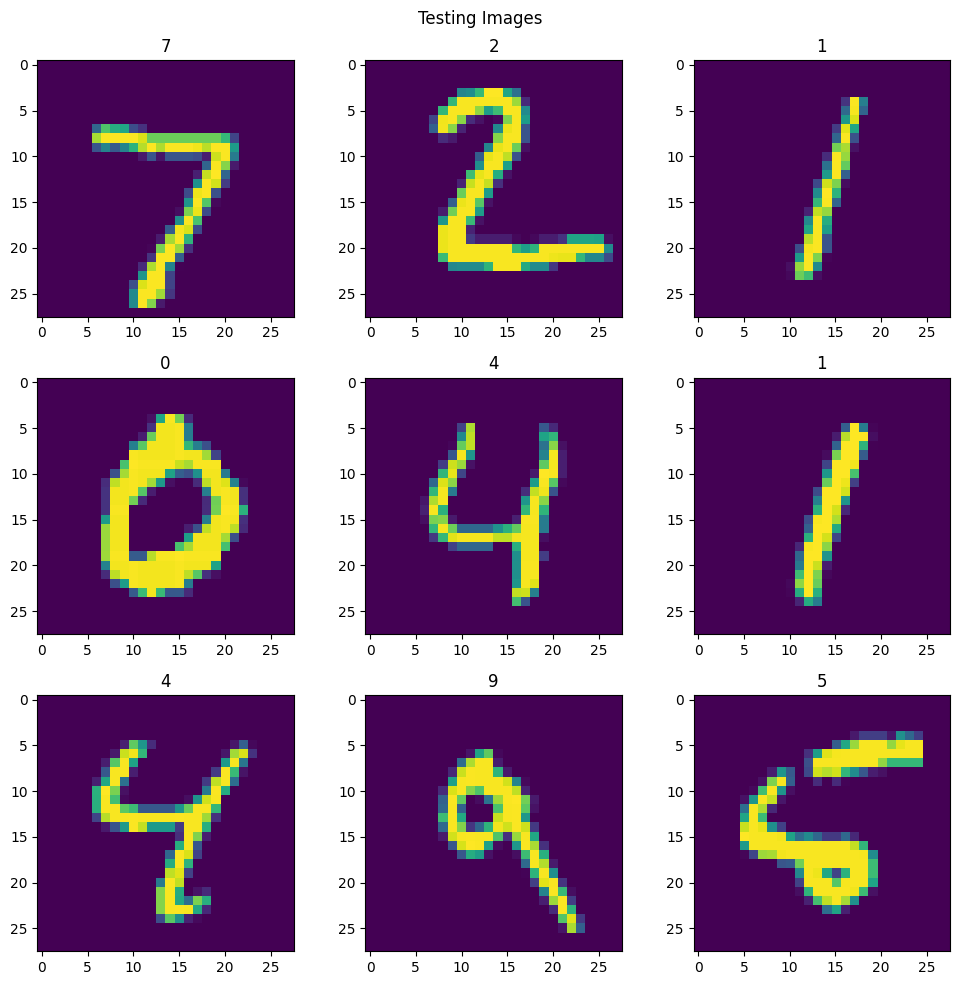

In [ ]:
plt.figure(figsize=(10, 10))

for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(X_test[i])
    plt.title(y_test[i])

plt.suptitle("Testing Images")
plt.tight_layout()
plt.show()

## Distribution of digits

### Training data

In [ ]:
unique_values, counts = np.unique(y_train, return_counts=True)
distribution_df = pd.DataFrame({'Digit': unique_values, 'Count': counts})

print("Distribution of digits in y_train:")
display(distribution_df)

Distribution of digits in y_train:


,Digit,Count
0,0,5923
1,1,6742
2,2,5958
3,3,6131
4,4,5842
5,5,5421
6,6,5918
7,7,6265
8,8,5851
9,9,5949


## Barplot

/tmp/ipykernel_2239/1658294423.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Digit', y='Count', data=distribution_df, palette='viridis')


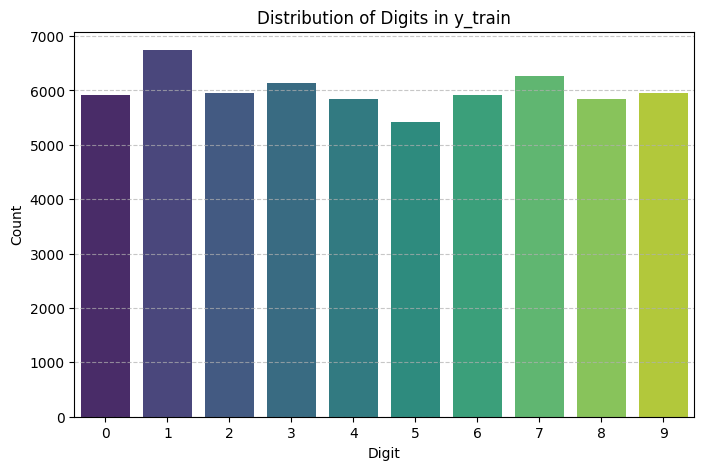

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(x='Digit', y='Count', data=distribution_df, palette='viridis')
plt.title('Distribution of Digits in y_train')
plt.xlabel('Digit')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Preprocessing

## Defining variables

In [ ]:
IMG_SIZE = (28, 28)
BATCH_SIZE = 32
EPOCHS = 20

## Normalisation

In [ ]:
print(np.max(X_train))

# Normalisation
X_train, X_test = X_train/255, X_test/255
print(X_train[0])

255
[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.

# MODEL 1: Basic ANN

## Preparing the neural netwrok (NN)

In [ ]:
model1 = Sequential([Flatten(input_shape=IMG_SIZE),
                   Dense(128, activation='relu'),
                   Dense(32, activation='relu'),
                   Dense(10, activation='softmax')])

model1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 104,938 (409.91 KB)

 Trainable params: 104,938 (409.91 KB)

 Non-trainable params: 0 (0.00 B)

## Training the NN

In [ ]:
model1.compile(loss='sparse_categorical_crossentropy', optimizer='Adam', metrics=['accuracy'])
history1 = model1.fit(X_train, y_train, epochs = EPOCHS, validation_split=0.2)

Epoch 1/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9147 - loss: 0.2938 - val_accuracy: 0.9572 - val_loss: 0.1464
Epoch 2/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9630 - loss: 0.1232 - val_accuracy: 0.9670 - val_loss: 0.1134
Epoch 3/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9752 - loss: 0.0828 - val_accuracy: 0.9687 - val_loss: 0.1050
Epoch 4/100
1498/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9806 - loss: 0.0635

KeyboardInterrupt: 

## Plotting model metrics

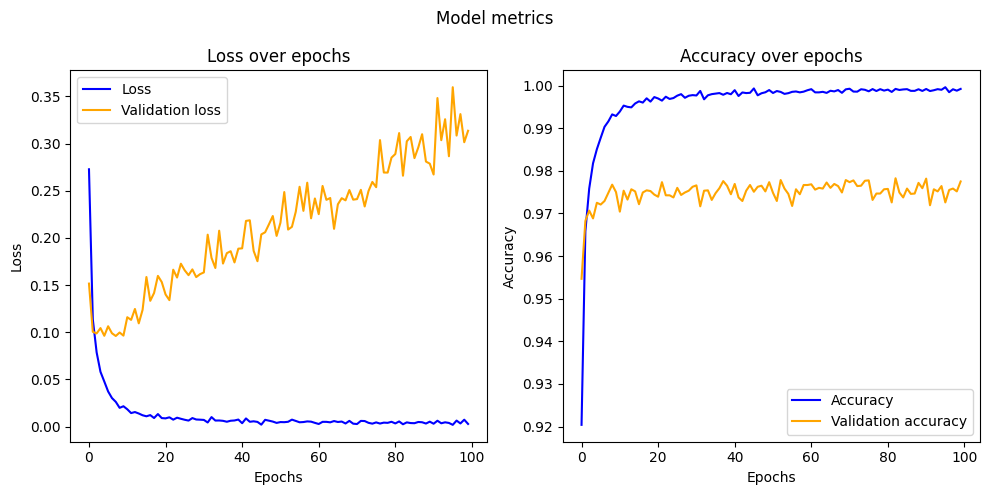

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# Loss
ax[0].plot(history1.history['loss'], color='blue', label='Loss')
ax[0].plot(history1.history['val_loss'], color='orange', label='Validation loss')
ax[0].set_title("Loss over epochs")
ax[0].set_ylabel("Loss")
ax[0].set_xlabel("Epochs")
ax[0].legend()
ax[0].grid()

# Accuracy
ax[1].plot(history1.history['accuracy'], color='blue', label='Accuracy')
ax[1].plot(history1.history['val_accuracy'], color='orange', label='Validation accuracy')
ax[1].set_title("Accuracy over epochs")
ax[1].set_ylabel("Accuracy")
ax[1].set_xlabel("Epochs")
ax[1].legend()
ax[1].grid()

fig.suptitle("Model metrics")
fig.tight_layout()
plt.show()

## Predicting output

In [ ]:
y_prob = model1.predict(X_test)
print(y_prob.shape)

y_pred = y_prob.argmax(axis=1)
print(y_pred.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
(10000, 10)
(10000,)


## Checking accuracy

In [ ]:
accuracy_score(y_pred, y_test)

0.9785

# MODEL 2: Improving the ANN

## Dropout layer, batch normalisation and He normal weight initialisation

In [ ]:
from tensorflow.keras.layers import Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

# Implementing dropout layer and batch normalisation
model2 = Sequential([Flatten(input_shape=IMG_SIZE),
                   Dense(128, activation='relu', kernel_initializer='he_normal'),
                     Dropout(0.2),
                   Dense(32, activation='relu', kernel_initializer='he_normal'),
                     BatchNormalization(),
                   Dropout(0.1),
                   Dense(10, activation='softmax')])

model2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105,066 (410.41 KB)

 Trainable params: 105,002 (410.16 KB)

 Non-trainable params: 64 (256.00 B)

## Early stopping

In [ ]:
early_stopping = EarlyStopping(monitor='val_loss',
                         min_delta = 1e-4,
                         patience=5,
                         verbose=1,
                         mode='auto',
                         baseline=None,
                         restore_best_weights=True)

## Compiling the model

In [ ]:
model2.compile(loss='sparse_categorical_crossentropy', optimizer='Adam', metrics=['accuracy'])
history2 = model2.fit(X_train, y_train, validation_split=0.2, epochs=EPOCHS, callbacks=early_stopping, batch_size=BATCH_SIZE)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8841 - loss: 0.3977 - val_accuracy: 0.9548 - val_loss: 0.1454
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9450 - loss: 0.1812 - val_accuracy: 0.9645 - val_loss: 0.1148
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9558 - loss: 0.1458 - val_accuracy: 0.9706 - val_loss: 0.1001
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9632 - loss: 0.1229 - val_accuracy: 0.9732 - val_loss: 0.0839
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9663 - loss: 0.1083 - val_accuracy: 0.9707 - val_loss: 0.0927
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9699 - loss: 0.0994 - val_accuracy: 0.9780 - val_loss: 0.0790
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9718 - loss: 0.0909 - val_accuracy: 0.9744 - val_loss: 0.0876
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9753 - loss: 0.0799 -

## Predicting output and accuracy

In [ ]:
y_prob = model2.predict(X_test)
print(y_prob.shape)

y_pred = y_prob.argmax(axis=1)
print(y_pred.shape)
accuracy_score(y_pred, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
(10000, 10)
(10000,)


0.9819

## Plotting

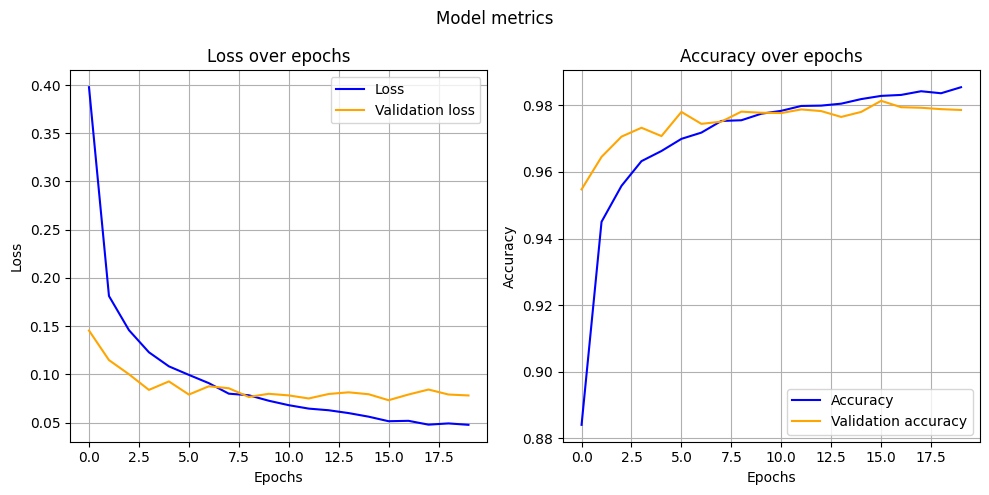

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# Loss
ax[0].plot(history2.history['loss'], color='blue', label='Loss')
ax[0].plot(history2.history['val_loss'], color='orange', label='Validation loss')
ax[0].set_title("Loss over epochs")
ax[0].set_ylabel("Loss")
ax[0].set_xlabel("Epochs")
ax[0].legend()
ax[0].grid()

# Accuracy
ax[1].plot(history2.history['accuracy'], color='blue', label='Accuracy')
ax[1].plot(history2.history['val_accuracy'], color='orange', label='Validation accuracy')
ax[1].set_title("Accuracy over epochs")
ax[1].set_ylabel("Accuracy")
ax[1].set_xlabel("Epochs")
ax[1].legend()
ax[1].grid()

fig.suptitle("Model metrics")
fig.tight_layout()
plt.show()

# MODEL 3: CNN

## Preparing the NN

In [ ]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Input, GlobalAveragePooling2D

model3 = Sequential([Input(shape=(28, 28, 1)),
                    # convolution layer 1
                   Conv2D(16, kernel_size=(3, 3), padding='valid', activation='relu'),
                   BatchNormalization(),
                   MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'),
                    # convolution layer 2
				   Conv2D(32, kernel_size=(3, 3), padding='valid', activation='relu'),
                    BatchNormalization(),
                   MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'),
                    # convolution layer 3
				   Conv2D(64, kernel_size=(3, 3), padding='valid', activation='relu'),
                    BatchNormalization(),
                   MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'),
                    # pooling layer
				   GlobalAveragePooling2D(),
                    # dense layer 1
                   Dense(128, activation='relu', kernel_initializer='he_normal'),
                    BatchNormalization(),
                    Dropout(0.2),
                    # dense layer 2
                   Dense(64, activation='relu', kernel_initializer='he_normal'),
                    BatchNormalization(),
                    Dropout(0.1),
                     # output layer
                   Dense(10, activation='softmax')])

model3.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 26, 26, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 11, 11, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 11, 11, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 3, 3, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 3, 3, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 1, 1, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_32          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_33          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41,738 (163.04 KB)

 Trainable params: 41,130 (160.66 KB)

 Non-trainable params: 608 (2.38 KB)

In [ ]:
model3.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history3 = model3.fit(X_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE, validation_split=0.2, callbacks=early_stopping)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - accuracy: 0.9152 - loss: 0.2809 - val_accuracy: 0.9736 - val_loss: 0.0871
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9682 - loss: 0.1056 - val_accuracy: 0.9795 - val_loss: 0.0632
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9751 - loss: 0.0807 - val_accuracy: 0.9835 - val_loss: 0.0566
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9799 - loss: 0.0671 - val_accuracy: 0.9822 - val_loss: 0.0609
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9818 - loss: 0.0591 - val_accuracy: 0.9826 - val_loss: 0.0620
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9853 - loss: 0.0484 - val_accuracy: 0.9868 - val_loss: 0.0449
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9855 - loss: 0.0451 - val_accuracy: 0.9866 - val_loss: 0.0484
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9879 - loss: 0.0389 

## Predicting output and accuracy

In [ ]:
y_prob = model3.predict(X_test)
print(y_prob.shape)

y_pred = y_prob.argmax(axis=1)
print(y_pred.shape)
accuracy_score(y_pred, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
(10000, 10)
(10000,)


0.9889

## Plotting loss and accuracy

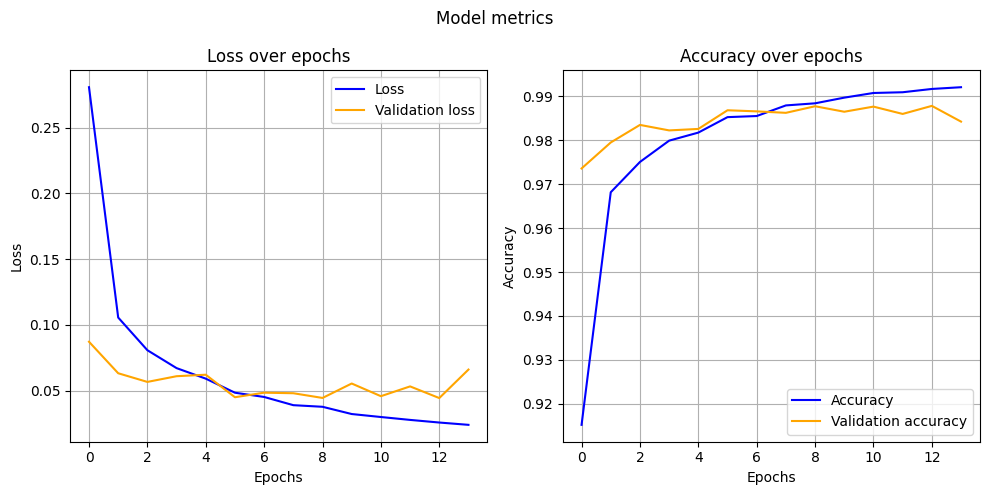

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# Loss
ax[0].plot(history3.history['loss'], color='blue', label='Loss')
ax[0].plot(history3.history['val_loss'], color='orange', label='Validation loss')
ax[0].set_title("Loss over epochs")
ax[0].set_ylabel("Loss")
ax[0].set_xlabel("Epochs")
ax[0].legend()
ax[0].grid()

# Accuracy
ax[1].plot(history3.history['accuracy'], color='blue', label='Accuracy')
ax[1].plot(history3.history['val_accuracy'], color='orange', label='Validation accuracy')
ax[1].set_title("Accuracy over epochs")
ax[1].set_ylabel("Accuracy")
ax[1].set_xlabel("Epochs")
ax[1].legend()
ax[1].grid()

fig.suptitle("Model metrics")
fig.tight_layout()
plt.show()

## Visualising predicted values

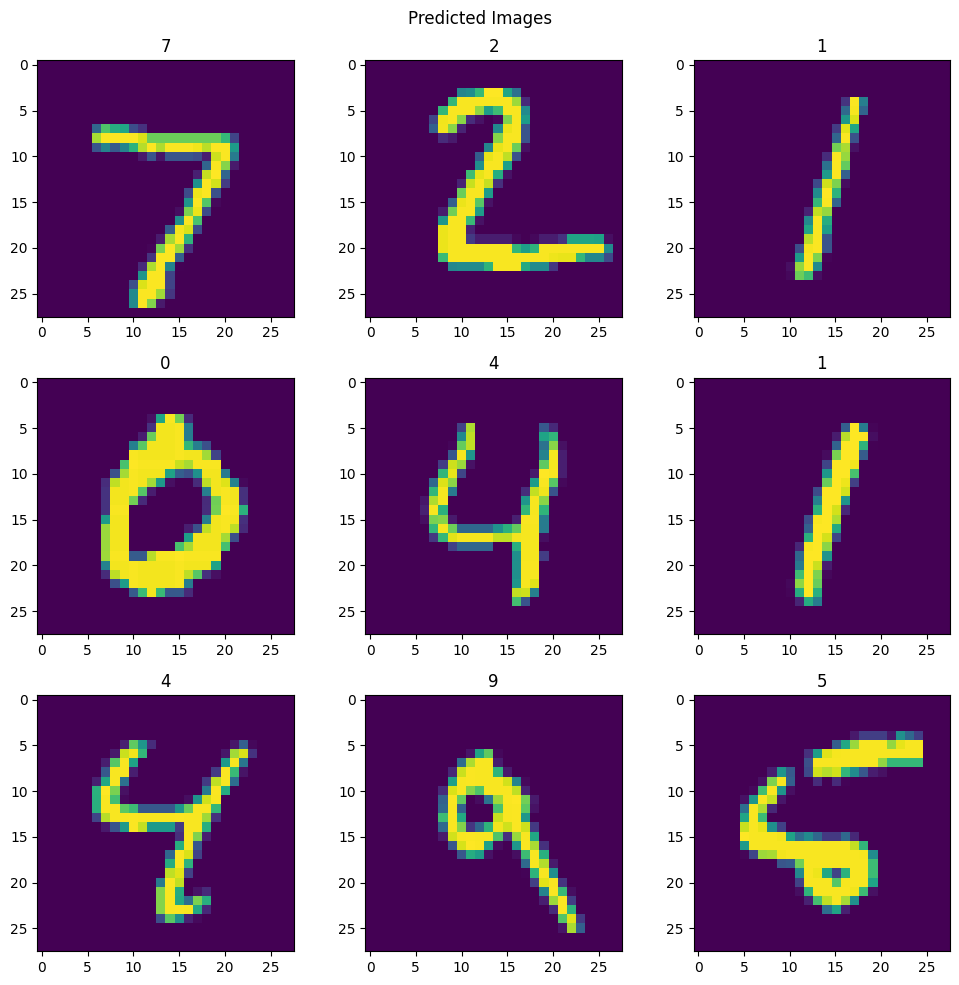

In [ ]:
plt.figure(figsize=(10, 10))

for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(X_test[i])
    plt.title(y_pred[i])

plt.suptitle("Predicted Images")
plt.tight_layout()
plt.show()